# Вариант А

Сначала загружаю изображение, перевожу его в оттенки серого и преобразую в массив NumPy.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error

img = Image.open("my_pic.jpg").convert("L")
original = np.array(img)

h, w = original.shape
original_shape = original.shape
original_flat = original.flatten()

A = original.astype(np.float32)

Выполняю SVD-разложение матрицы изображения. Затем восстанавливаю изображение для разных рангов.

In [4]:
U, s, Vt = np.linalg.svd(A, full_matrices=False)

list_of_ranks = [1, 5, 10, 30, 100, min(h, w)]

approximations = []
compression_ratios = []

original_size = h * w

for r in list_of_ranks:
    approx = (U[:, :r] * s[:r]) @ Vt[:r, :]
    approx = np.clip(approx, 0, 255)

    approximations.append(approx)

    compressed_size = r * (h + 1 + w) * 4
    compression_ratios.append(original_size / compressed_size)

Вывожу шесть вариантов изображения и оригинал и указываю для каждого ранг и рассчитанный коэффициент сжатия.

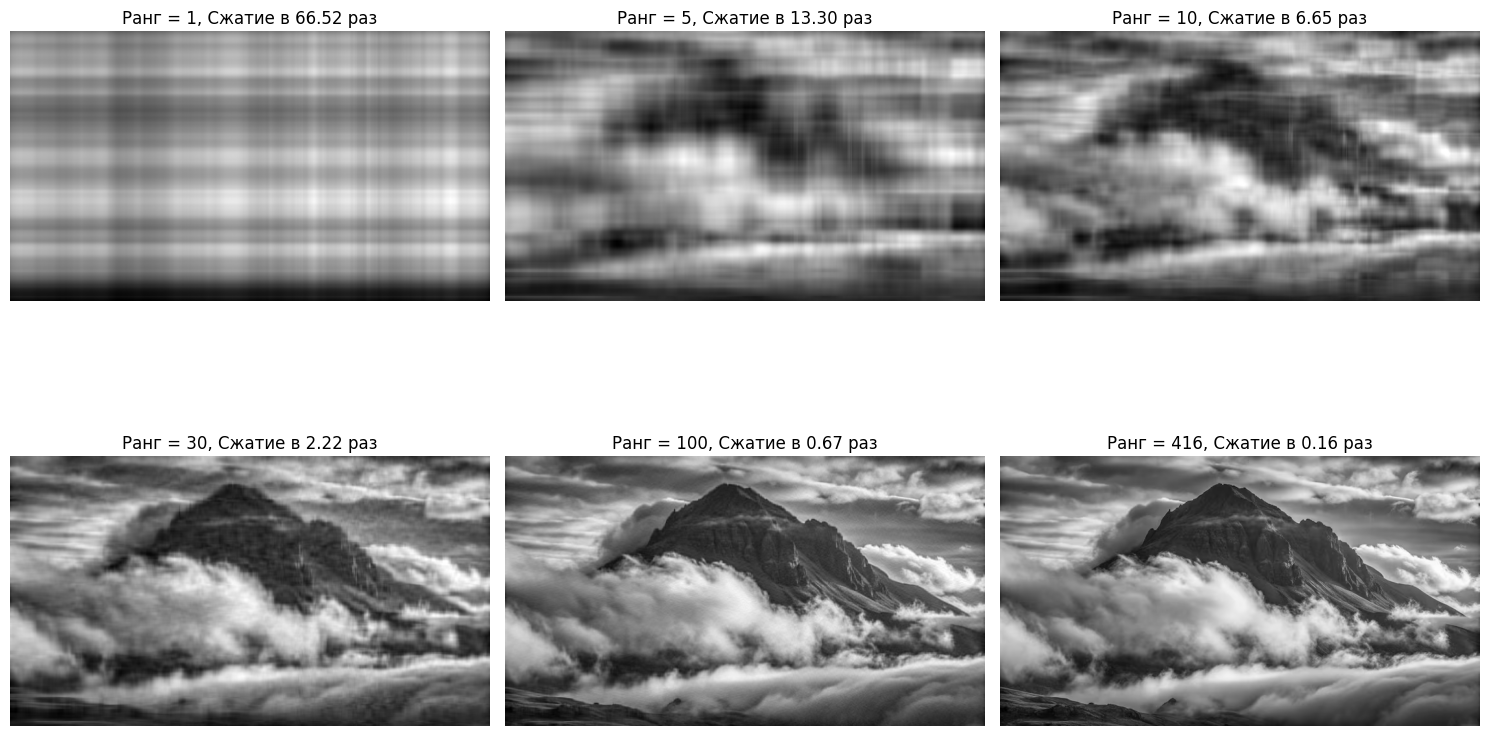

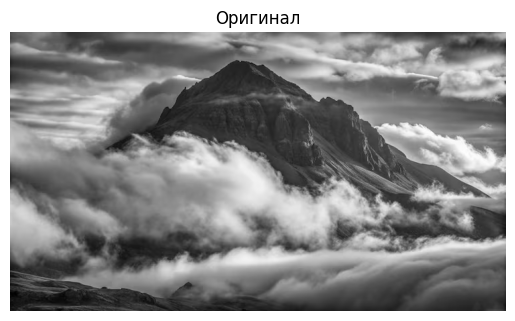

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, approx, r, ratio in zip(
    axes.flat,
    approximations,
    list_of_ranks,
    compression_ratios
):
    ax.imshow(approx, cmap="gray")
    ax.set_title(f"Ранг = {r}, Сжатие в {ratio:.2f} раз")
    ax.axis("off")

plt.tight_layout()
plt.show()
plt.imshow(original, cmap="gray")
plt.title("Оригинал")
plt.axis("off")
plt.show()

In [6]:
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

✅ Все автоматические проверки пройдены. Задание выполнено корректно!


# Ответы на вопросы

1. При каком ранге визуальное качество перестает отличаться от оригинала?

В случае данного фото при ранге 100 изображение уже визуально очень близко к оригиналу.

2. Для какого ранга достигается сжатие в 10 раз?

Для данного изображения сжатие в 10 раз достигается при ранге 5-10.

3. Почему для тёмных и светлых участков ошибка разная?

SVD восстанавливает изображение приближённо и сохраняет более общую структуру, поэтому ошибка распределяется по изображению неравномерно (на участках с резкими переходами яркости и большим количеством деталей она обычно заметнее, а на более однородных участках менее).

# Вариант В

Загружаю изображение в формате RGB и преобразую его в массив NumPy. Применяю SVD отдельно к красному, зелёному и синему каналам. Затем задаю ранги, для которых будет выполняться восстановление изображения.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error
img = Image.open("my_pic.jpg").convert("RGB")
original = np.array(img)

h, w, c = original.shape
original_shape = original.shape
original_flat = original.flatten()

channels = original.transpose(2, 0, 1).astype(np.float32)
U, s, Vt = np.linalg.svd(channels, full_matrices=False)
list_of_ranks = [1, 5, 10, 30, 100, min(h, w)]

approximations = []
compression_ratios = []

original_size = 3 * h * w

for r in list_of_ranks:
    approx = (U[:, :, :r] * s[:, None, :r]) @ Vt[:, :r, :]
    approx = approx.transpose(1, 2, 0)
    approx = np.clip(approx, 0, 255)
    approximations.append(approx)
    compressed_size = 3 * r * (h + 1 + w) * 4
    compression_ratios.append(original_size / compressed_size)

Для каждого ранга восстанавливаю сразу три цветовых канала, после чего объединяю их обратно в RGB-изображение. Также вычисляю коэффициент сжатия для каждого ранга.

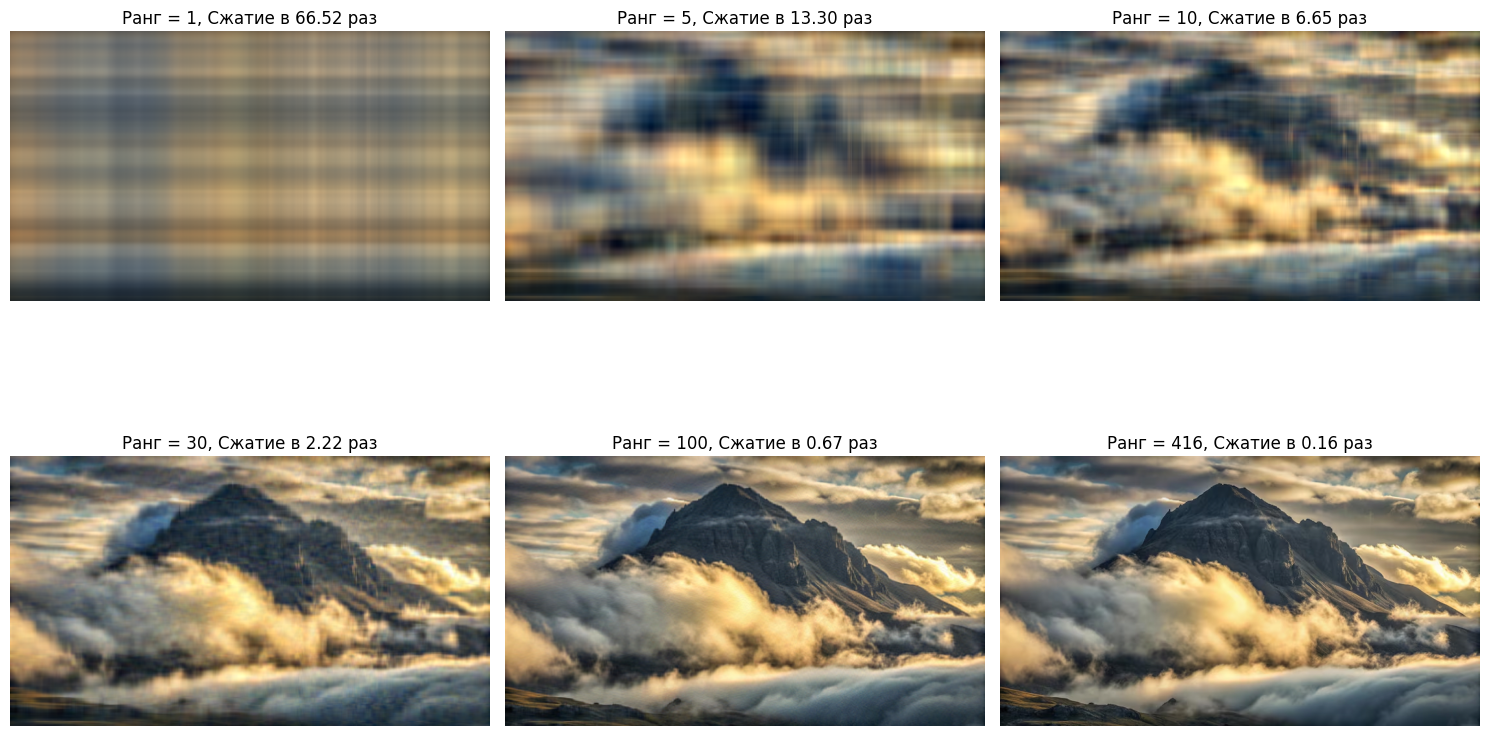

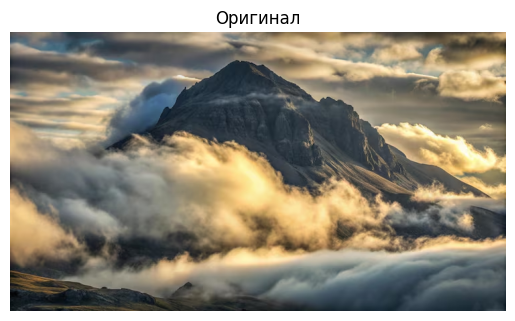

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, approx, r, ratio in zip(
    axes.flat,
    approximations,
    list_of_ranks,
    compression_ratios
):
    ax.imshow(approx.astype(np.uint8))
    ax.set_title(f"Ранг = {r}, Сжатие в {ratio:.2f} раз")
    ax.axis("off")

plt.tight_layout()
plt.show()
plt.imshow(original)
plt.title("Оригинал")
plt.axis("off")
plt.show()

Вывожу шесть восстановленных RGB-изображений и оригинал. Для каждого указываю ранг и рассчитанный коэффициент сжатия.

In [9]:
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

✅ Все автоматические проверки пройдены. Задание выполнено корректно!


# Выводы

В работе было выполнено сжатие изображения с помощью SVD для двух вариантов: изображения в градациях серого и цветного RGB-изображения. Было видно, что при маленьком ранге сжатие сильнее, но качество изображения хуже. При увеличении ранга изображение становится ближе к оригиналу, но коэффициент сжатия уменьшается.

Для RGB-варианта SVD применялось отдельно к каждому цветовому каналу, поэтому удалось сохранить цветное изображение. SVD позволяет подобрать нужный баланс между качеством изображения и степенью его сжатия.